# 1. Imports 



In [ ]:
import math
import numpy as np
import pandas as pd
import random
import pickle
import warnings
import inflection
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

from scipy                 import stats as ss
from boruta                import BorutaPy
from matplotlib            import pyplot as pl
from IPython.display       import Image
from IPython.core.display  import HTML



from sklearn.metrics       import mean_absolute_error, mean_squared_error
from sklearn.ensemble      import RandomForestRegressor
from sklearn.linear_model  import LinearRegression, Lasso
from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder

warnings.filterwarnings( 'ignore' )

In [ ]:
#Loading data
df_sales_raw  = pd.read_csv(r'C:\Users\miks-\OneDrive\Área de Trabalho\Estudos\Rossmann\train.csv' , low_memory=False)
df_store_raw  = pd.read_csv(r'C:\Users\miks-\OneDrive\Área de Trabalho\Estudos\Rossmann\store.csv' , low_memory=False)

df_merge = pd.merge( df_sales_raw , df_store_raw  , on='Store' , how='left')

## 1.1Helper Functions

In [ ]:
def cross_validation(x_training, kfold, model_name, model, verbose=False):
    mae_list = []
    mape_list = []
    rmse_list = []
    
    for k in reversed(range(1, kfold+1)):
        if verbose:
            print('\nKFold Número: {}'.format(k))
        
        # intervalo de validação (6 semanas por fold)
        validation_start_date = x_training['date'].max() - datetime.timedelta(days=k*6*7)
        validation_end_date   = x_training['date'].max() - datetime.timedelta(days=(k-1)*6*7)
        
        # separação treino/validação
        training   = x_training[x_training['date'] < validation_start_date]
        validation = x_training[(x_training['date'] >= validation_start_date) & 
                                (x_training['date'] <= validation_end_date)]
        
        # features e target
        xtraining   = training.drop(['date', 'sales'], axis=1)
        ytraining   = training['sales']
        xvalidation = validation.drop(['date', 'sales'], axis=1)
        yvalidation = validation['sales']
        
        # treino do modelo
        m = model.fit(xtraining, ytraining)
        
        # previsão
        yhat = m.predict(xvalidation)
        
        # cálculo das métricas
        m_result = ml_error(model_name, np.expm1(yvalidation), np.expm1(yhat))
        
        # armazenar resultados
        mae_list.append(m_result['MAE'])
        mape_list.append(m_result['MAPE'])
        rmse_list.append(m_result['RMSE'])
    
    # resumo final
    return pd.DataFrame({
        'Model Name': model_name,
        'MAE CV':  f"{np.round(np.mean(mae_list), 2)} +/- {np.round(np.std(mae_list), 2)}",
        'MAPE CV': f"{np.round(np.mean(mape_list), 2)} +/- {np.round(np.std(mape_list), 2)}",
        'RMSE CV': f"{np.round(np.mean(rmse_list), 2)} +/- {np.round(np.std(rmse_list), 2)}"
    }, index=[0])
    
def mean_percentage_error( y, yhat ):
    return np.mean( ( y- yhat ) / y )

def mean_absolute_percentage_error( y, yhat ):
    return np.mean( np.abs( ( y- yhat ) / y ) )

def ml_error( model_name, y, yhat ):
    mae = mean_absolute_error( y, yhat )
    mape = mean_absolute_percentage_error( y, yhat )
    rmse = np.sqrt( mean_squared_error( y, yhat ) )
    return pd.DataFrame( { 'Model Name': model_name,
                            'MAE': mae,
                            'MAPE': mape,
                            'RMSE': rmse }, index=[0] )

# 2. Descriçao dos Dados

In [ ]:
df = df_merge.copy()

In [ ]:
df.dtypes

Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

In [ ]:
# Transformar o campo Date em Data.
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object

In [ ]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [ ]:
# Rename Columns
cols_old =  ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo','StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment','CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek','Promo2SinceYear', 'PromoInterval']

snakecase = lambda x: inflection.underscore( x )

cols_new = list( map( snakecase, cols_old ) )

# rename
df.columns = cols_new

In [ ]:
df.head()

,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,promo_interval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
#Check NA
df.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

In [ ]:
#competition_distance
df['competition_distance'] =  df['competition_distance'].apply( lambda x: 200000.0 if math.isnan( x ) else x )

#competition_open_since_month
df['competition_open_since_month'] = df.apply( lambda x: x['date'].month if math.isnan( x['competition_open_since_month'] ) else  x['competition_open_since_month'], axis = 1  )

#competition_open_since_year
df['competition_open_since_year'] = df.apply( lambda x: x['date'].year if math.isnan( x['competition_open_since_year'] ) else  x['competition_open_since_year'], axis = 1  )

#promo2_since_week
df['promo2_since_week'] = df.apply( lambda x: x['date'].week if math.isnan( x['promo2_since_week'] ) else  x['promo2_since_week'], axis = 1  )

#promo2_since_year
df['promo2_since_year'] = df.apply( lambda x: x['date'].year if math.isnan( x['promo2_since_year'] ) else  x['promo2_since_year'], axis = 1  )

#promo_interval
month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

df['promo_interval'].fillna(0, inplace=True )

df['month_map'] = df['date'].dt.month.map( month_map )

df['is_promo'] = df[['promo_interval', 'month_map']].apply( lambda x: 0 if x['promo_interval'] == 0 else 1 if x['month_map'] in x['promo_interval'].split( ',' ) else 0, axis=1 )

In [ ]:
df.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
customers                       0
open                            0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
promo_interval                  0
month_map                       0
is_promo                        0
dtype: int64

In [ ]:
#Data Dimensions
print( 'Number of Rows: {}'.format( df.shape[0] ) )
print( 'Number of Cols: {}'.format( df.shape[1] ) )

Number of Rows: 1017209
Number of Cols: 20


In [ ]:
#Change Data Types
# competiton
df['competition_open_since_month'] = df['competition_open_since_month'].astype( int )
df['competition_open_since_year'] = df['competition_open_since_year'].astype( int )

# promo2
df['promo2_since_week'] = df['promo2_since_week'].astype( int )
df['promo2_since_year'] = df['promo2_since_year'].astype( int )

In [ ]:
#Descriptive Statistics
num_attributes = df.select_dtypes( include=['int64', 'float64'] )
cat_attributes = df.select_dtypes( exclude=['int64', 'float64','datetime64[ns]'] )

In [ ]:
#Numerical Atributes
# Central Tendency- mean, meadina
ct1 = pd.DataFrame( num_attributes.apply( np.mean ) ).T
ct2 = pd.DataFrame( num_attributes.apply( np.median ) ).T

# dispersion- std, min, max, range, skew, kurtosis
d1 = pd.DataFrame( num_attributes.apply( np.std ) ).T
d2 = pd.DataFrame( num_attributes.apply( min ) ).T
d3 = pd.DataFrame( num_attributes.apply( max ) ).T
d4 = pd.DataFrame( num_attributes.apply( lambda x: x.max()- x.min() ) ).T
d5 = pd.DataFrame( num_attributes.apply( lambda x: x.skew() ) ).T
d6 = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() ) ).T

# concatenar
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std','skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


<Axes: xlabel='competition_distance'>

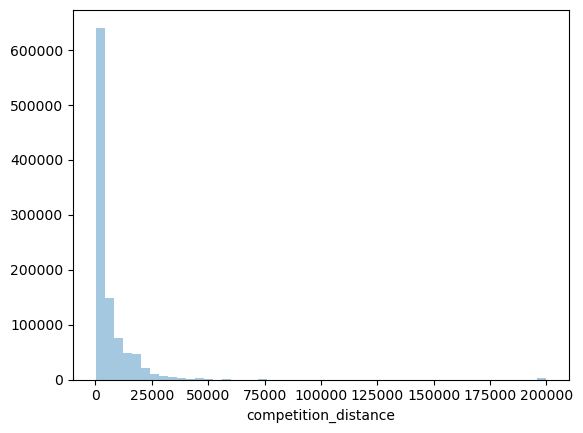

In [ ]:
sns.distplot( df['competition_distance'], kde=False )

In [ ]:
#Categorical Atributes
cat_attributes.apply( lambda x: x.unique().shape[0] )

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

In [ ]:
import matplotlib.pyplot as plt

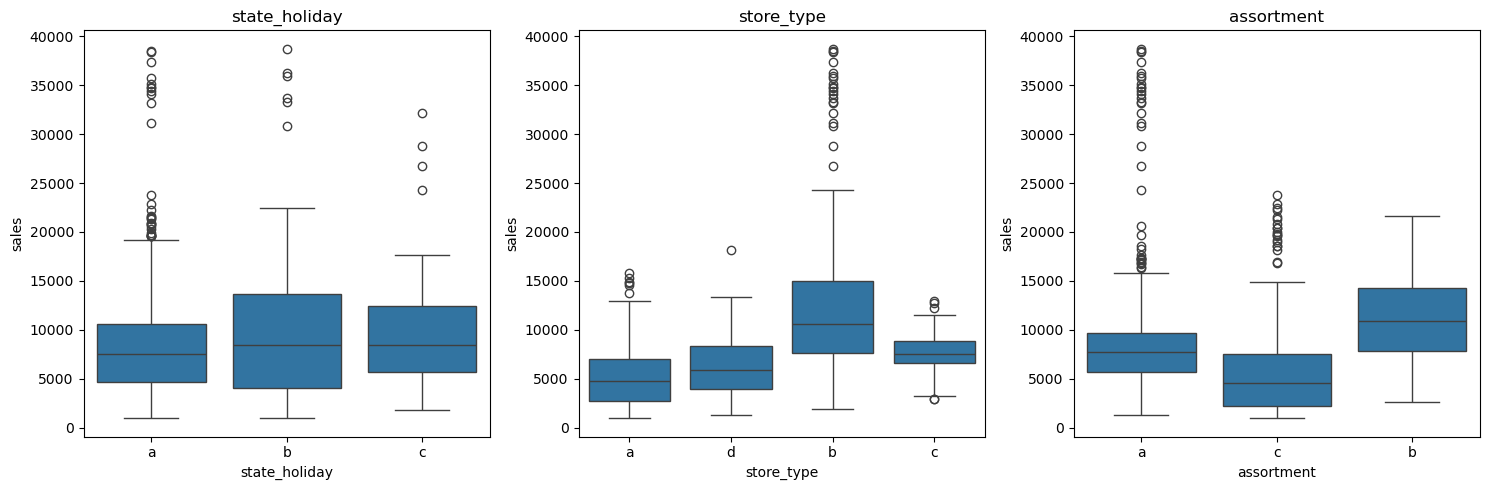

In [ ]:
aux = df[(df['state_holiday'] != '0') & (df['sales'] > 0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='state_holiday', y='sales', data=aux, ax=axes[0])
axes[0].set_title("state_holiday")

sns.boxplot(x='store_type', y='sales', data=aux, ax=axes[1])
axes[1].set_title("store_type")

sns.boxplot(x='assortment', y='sales', data=aux, ax=axes[2])
axes[2].set_title("assortment")

plt.tight_layout()
plt.show()


# 3. Feature Engineering

In [ ]:
df2 = df.copy()

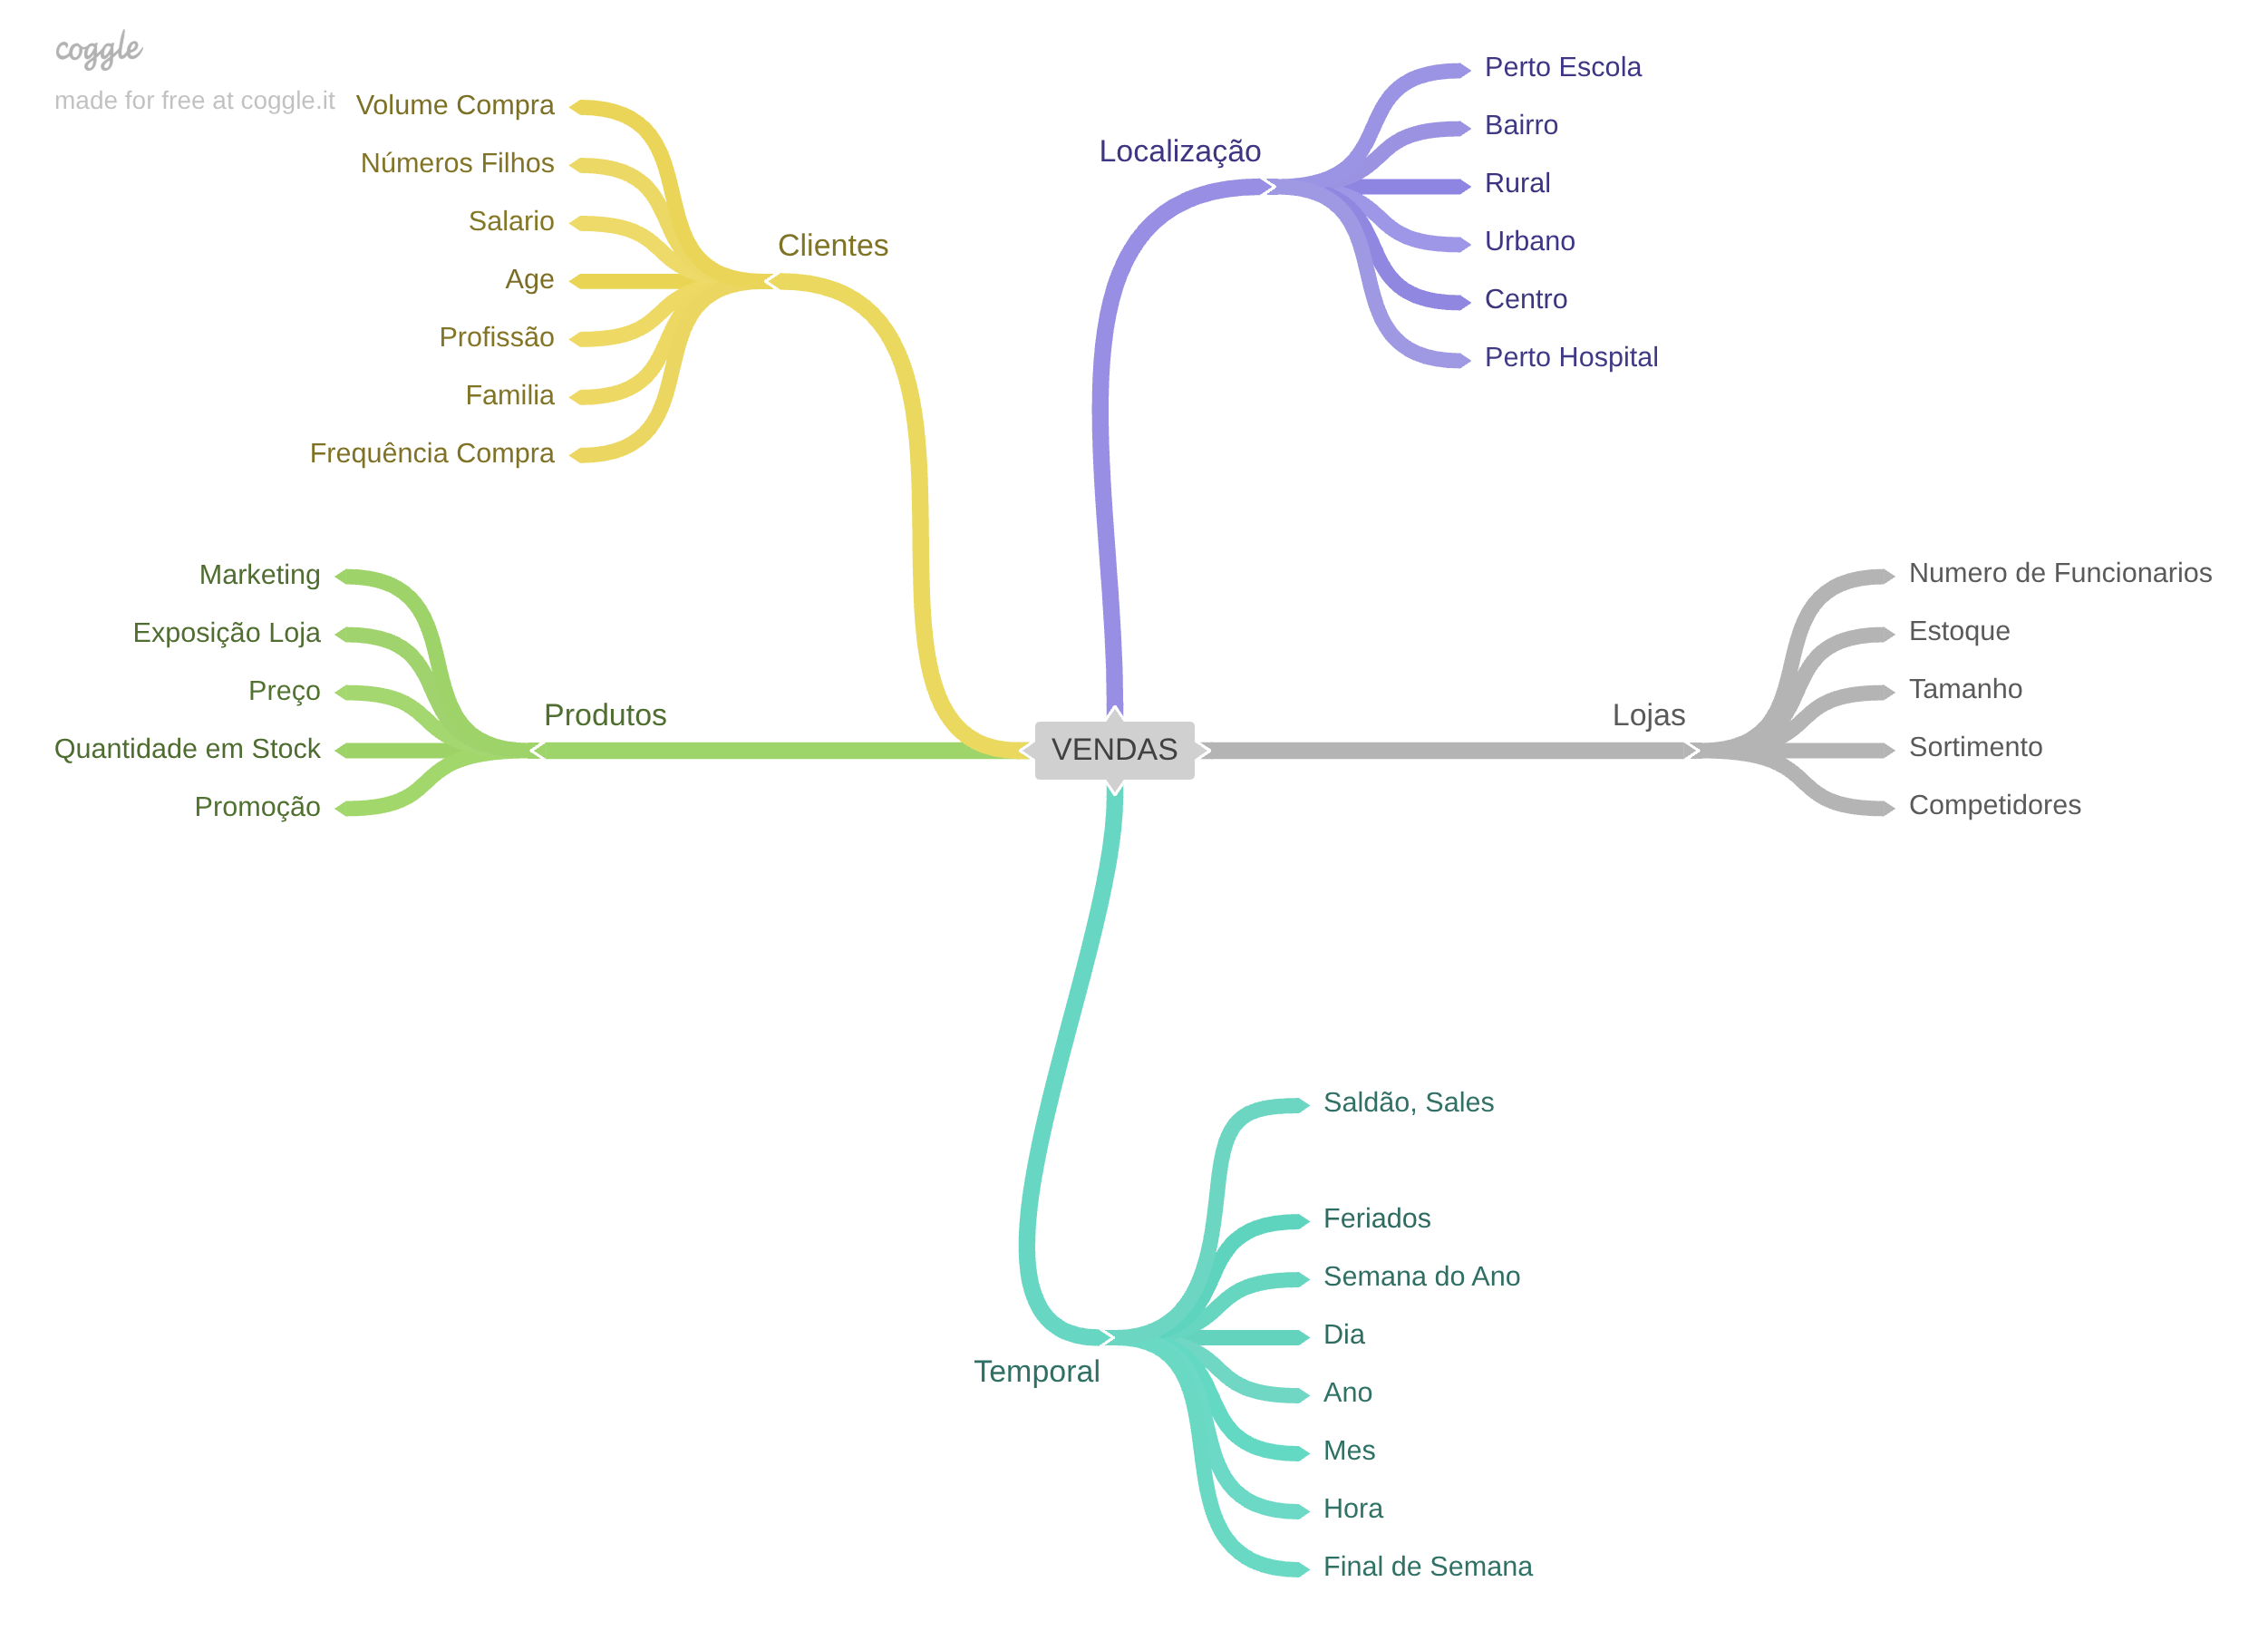

In [ ]:
Image( 'Favorites/VENDAS.png' )

In [ ]:
#Feature Engineering
#year
df2['year'] = df2['date'].dt.year

#month
df2['month'] = df2['date'].dt.month

#day
df2['day'] = df2['date'].dt.day

#week of year
df2['week_of_year'] = df2['date'].dt.isocalendar().week

#year week
df2['year_week'] = df2['date'].dt.strftime( '%Y-%W' )

# competition since
df2['competition_since'] = df2.apply( lambda x: datetime.datetime(year=x['competition_open_since_year'],month=x['competition_open_since_month'],day=1 ), axis=1 )
df2['competition_time_month'] = ( ( df2['date']- df2['competition_since'] )/30).apply( lambda x: x.days ).astype( int )

# promo since
df2['promo_since'] = df2['promo2_since_year'].astype( str ) + '-' +df2['promo2_since_week'].astype( str )
df2['promo_since'] = df2['promo_since'].apply( lambda x: datetime.datetime.strptime( x + '-1', '%Y-%W-%w' )- datetime.timedelta( days=7 ) )
df2['promo_time_week'] = ( ( df2['date']- df2['promo_since'] )/7 ).apply(lambda x: x.days ).astype( int )

# assortment
df2['assortment'] = df2['assortment'].apply( lambda x: 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended' )

# state holiday
df2['state_holiday'] = df2['state_holiday'].apply( lambda x: 'public_holiday'if x == 'a' else 'easter_holiday' if x == 'b' else 'christmas' if x == 'c' else 'regular_day' )



In [ ]:
df2.head().T

,0,1,2,3,4
store,1,2,3,4,5
day_of_week,5,5,5,5,5
date,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00
sales,5263,6064,8314,13995,4822
customers,555,625,821,1498,559
open,1,1,1,1,1
promo,1,1,1,1,1
state_holiday,regular_day,regular_day,regular_day,regular_day,regular_day
school_holiday,1,1,1,1,1
store_type,c,a,a,c,a


# 4. Filtragem de Variáveis

In [ ]:
df3 = df2.copy()

In [ ]:
df3 = df3[(df3['open'] != 0) & ( df3['sales'] > 0 )]

In [ ]:
cols_drop =  ['customers', 'open', 'promo_interval', 'month_map']

df3 = df3.drop( cols_drop, axis = 1 )

# 5. Analise Exploratória

## 4.1 Analise Univariavel 

### 4.1.1 Response Variable

In [ ]:
df4 = df3.copy()

<Axes: xlabel='sales', ylabel='Density'>

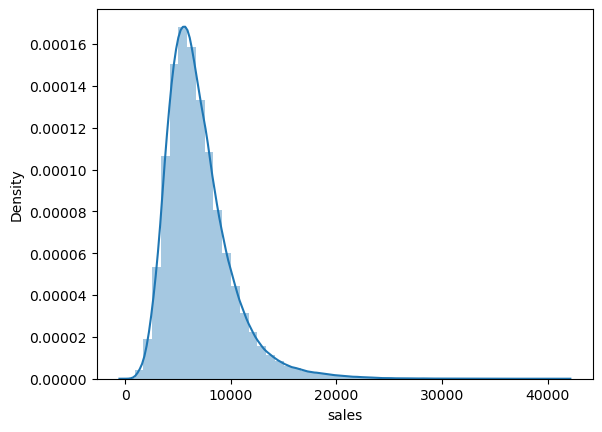

In [ ]:
sns.distplot (df4['sales'] )

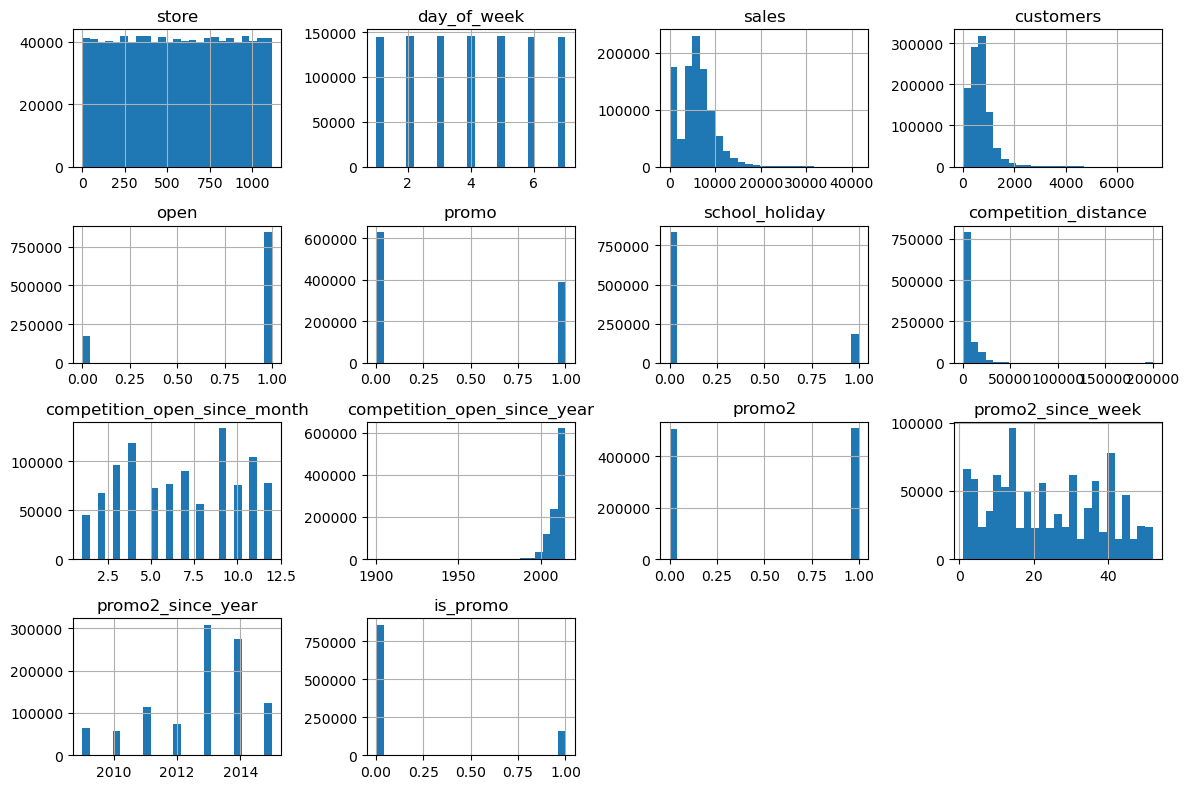

In [ ]:
num_attributes.hist( bins= 25, figsize=(12,8), label='Histograma' );
plt.tight_layout()

### 4.1.3 Categorical Variable

In [ ]:
cat_attributes.head()

,state_holiday,store_type,assortment,promo_interval,month_map
0,0,c,a,0,Jul
1,0,a,a,"Jan,Apr,Jul,Oct",Jul
2,0,a,a,"Jan,Apr,Jul,Oct",Jul
3,0,c,c,0,Jul
4,0,a,a,0,Jul


### 4.1.2 Numerical Variable

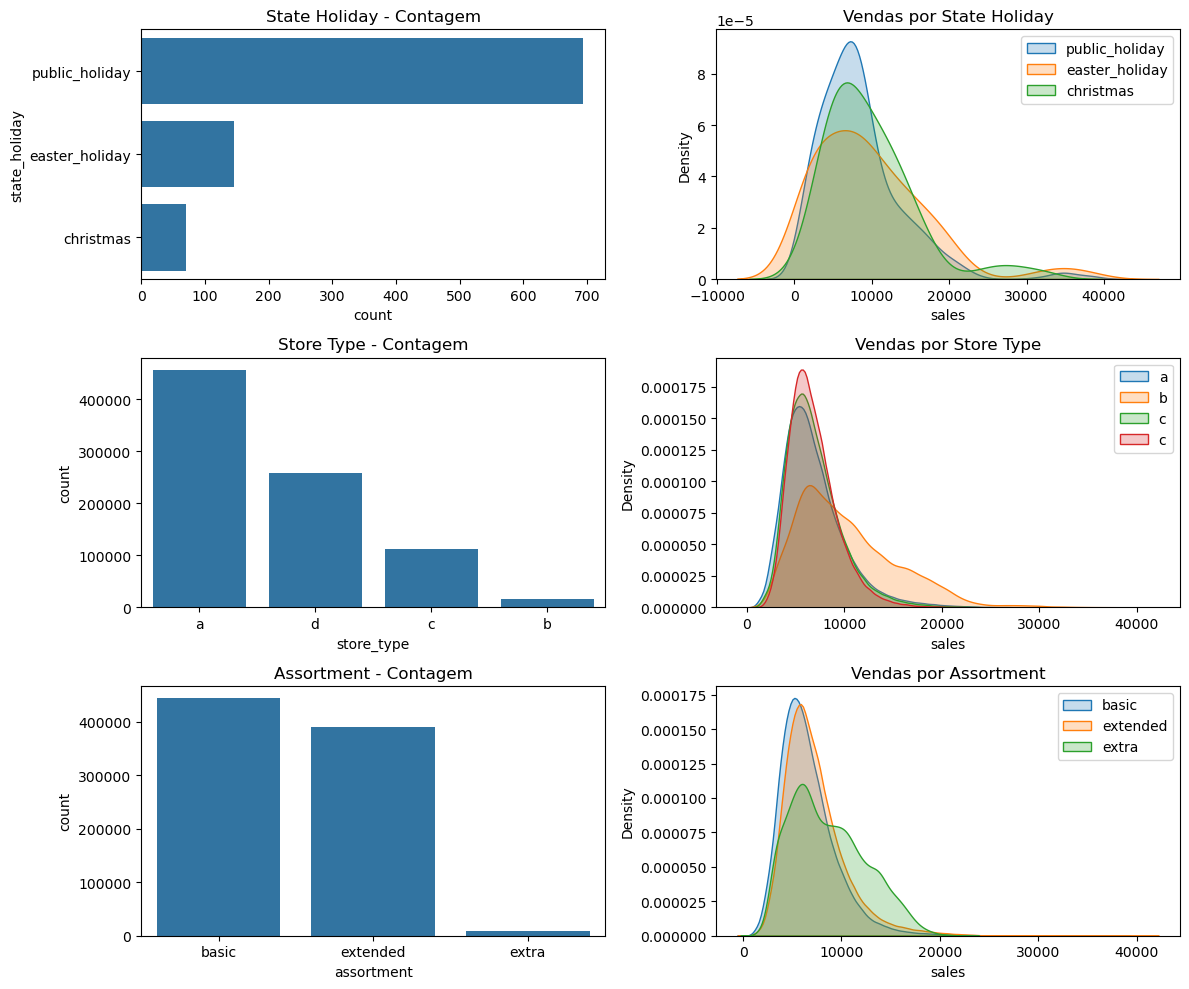

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(12, 10))

#state_holiday -----------------------------

df_holiday = df4[df4['state_holiday'] != 'regular_day']

sns.countplot(
    y=df_holiday['state_holiday'],
    order=df_holiday['state_holiday'].value_counts().index,
    ax=ax[0,0]
)
ax[0,0].set_title("State Holiday - Contagem")

sns.kdeplot(df_holiday[df_holiday['state_holiday']=='public_holiday']['sales'],
            label='public_holiday', shade=True, ax=ax[0,1])
sns.kdeplot(df_holiday[df_holiday['state_holiday']=='easter_holiday']['sales'],
            label='easter_holiday', shade=True, ax=ax[0,1])
sns.kdeplot(df_holiday[df_holiday['state_holiday']=='christmas']['sales'],
            label='christmas', shade=True, ax=ax[0,1])
ax[0,1].legend()
ax[0,1].set_title("Vendas por State Holiday")


# store_type ------------------------------

sns.countplot(
    x=df4['store_type'],
    order=df4['store_type'].value_counts().index,
    ax=ax[1,0]
)
ax[1,0].set_title("Store Type - Contagem")

sns.kdeplot(df4[df4['store_type']=='a']['sales'], label='a', shade=True, ax=ax[1,1])
sns.kdeplot(df4[df4['store_type']=='b']['sales'], label='b', shade=True, ax=ax[1,1])
sns.kdeplot(df4[df4['store_type']=='c']['sales'], label='c', shade=True, ax=ax[1,1])
sns.kdeplot(df4[df4['store_type']=='d']['sales'], label='c', shade=True, ax=ax[1,1])
ax[1,1].legend()
ax[1,1].set_title("Vendas por Store Type")


# assortment --------------------------------
sns.countplot(
    x=df4['assortment'],
    order=df4['assortment'].value_counts().index,
    ax=ax[2,0]
)
ax[2,0].set_title("Assortment - Contagem")

sns.kdeplot(df4[df4['assortment']=='basic']['sales'], label='basic', shade=True, ax=ax[2,1])
sns.kdeplot(df4[df4['assortment']=='extended']['sales'], label='extended', shade=True, ax=ax[2,1])
sns.kdeplot(df4[df4['assortment']=='extra']['sales'], label='extra', shade=True, ax=ax[2,1])
ax[2,1].legend()
ax[2,1].set_title("Vendas por Assortment")

plt.tight_layout()
plt.show()


## 4.2 Analise Bivariavel

## 4.3 Analise Multivariavel


### 4.3.1 Numeral Attributes

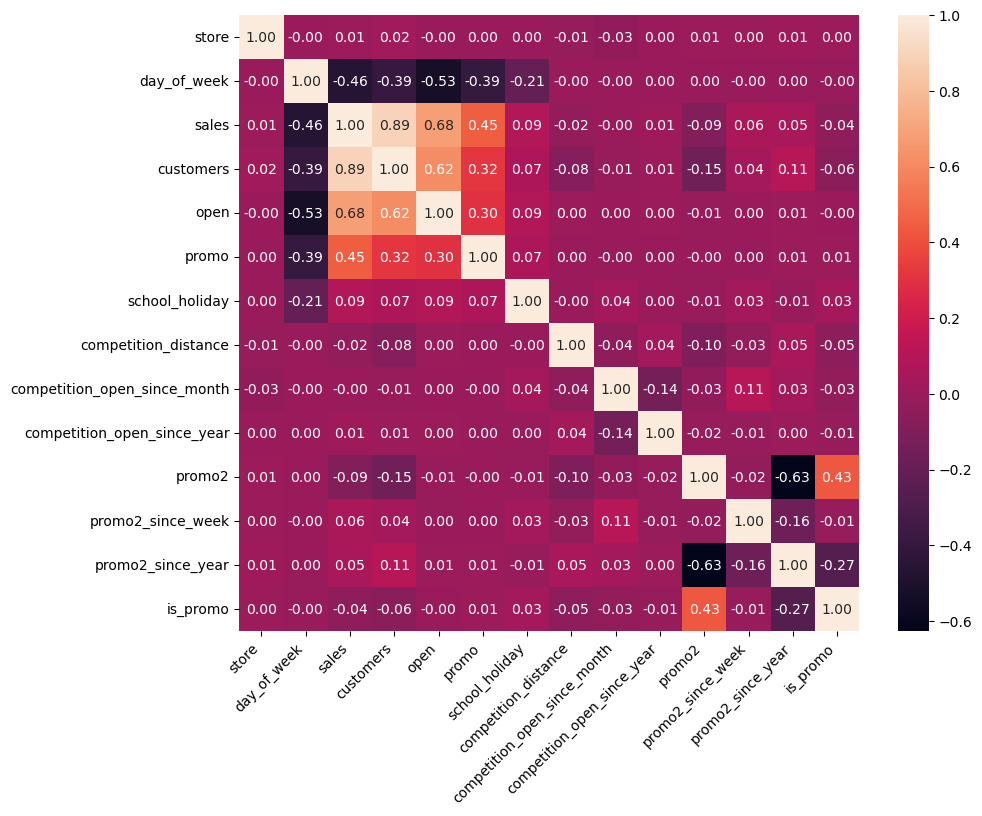

In [ ]:
plt.figure(figsize=(10, 8))

correlation = num_attributes.corr(method='pearson')

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()


### 4.3.2 Categorical Attributes

In [ ]:
a = df4.select_dtypes( include='object' )
a.head()

,state_holiday,store_type,assortment,year_week
0,regular_day,c,basic,2015-30
1,regular_day,a,basic,2015-30
2,regular_day,a,basic,2015-30
3,regular_day,c,extended,2015-30
4,regular_day,a,basic,2015-30


In [ ]:
def cramer_v ( x, y ):
    cm = pd.crosstab( x, y ).to_numpy()
    n = cm.sum()
    r, k = cm.shape

    chi2 = ss.chi2_contingency( cm ) [0]
    chi2corr = max( 0, chi2 - ( k-1)*(r-1)/(n-1) )
    kcorr = k - (k-1)**2/(n-1)
    rcorr = r - (k-1)**2/(n-1)

    return np.sqrt ( ( chi2/n ) / ( min( k-1, r-1 )))

<Axes: >

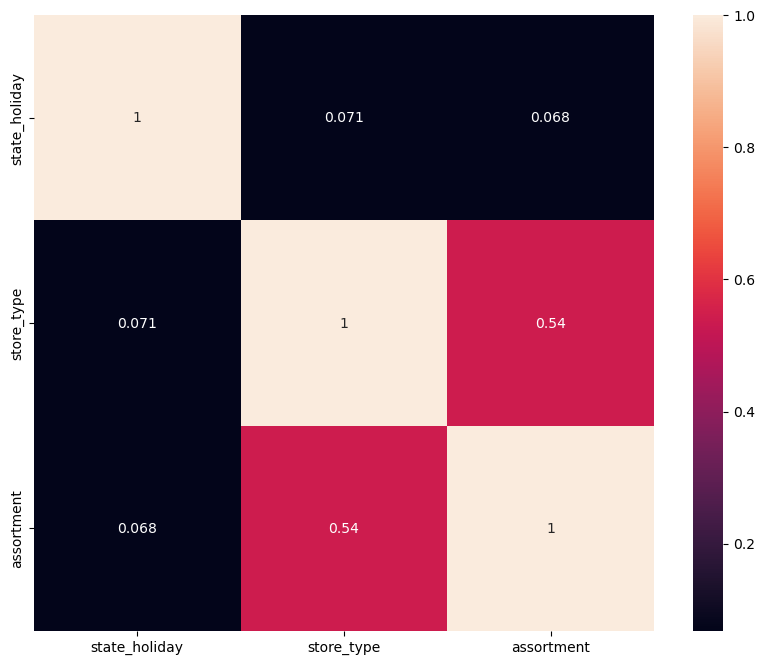

In [ ]:
## v = np.sqrt ( ( chi2/n ) / ( min(k-1, r-1 ) ) )

a = df4.select_dtypes( include='object' )

# Calculate cramer V
a1 = cramer_v( a['state_holiday'], a['state_holiday'] )
a2 = cramer_v( a['state_holiday'], a['store_type'] )
a3 = cramer_v( a['state_holiday'], a['assortment'] )

a4 = cramer_v( a['store_type'], a['state_holiday'] )
a5 = cramer_v( a['store_type'], a['store_type'] )
a6 = cramer_v( a['store_type'], a['assortment'] )

a7 = cramer_v( a['assortment'], a['state_holiday'] )
a8 = cramer_v( a['assortment'], a['store_type'] )
a9 = cramer_v( a['assortment'], a['assortment'] )

# Final dataset
d = pd.DataFrame( {'state_holiday': [a1, a2, a3],
'store_type': [a4, a5, a6],
'assortment': [a7, a8, a9] })

d = d.set_index( d.columns )

plt.figure(figsize=(10, 8))
sns.heatmap( d, annot=True )

# 6. Data Preparation

## ~~6.1.1 Normalização~~

## 6.1.2 Rescaling

In [ ]:
df5 = df4.copy()
df5.head()

,store,day_of_week,date,sales,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,...,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,1,regular_day,1,c,basic,1270.0,...,0,2015,7,31,31,2015-30,2008-09-01,84,2015-07-27,0
1,2,5,2015-07-31,6064,1,regular_day,1,a,basic,570.0,...,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,1,regular_day,1,a,basic,14130.0,...,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1,regular_day,1,c,extended,620.0,...,0,2015,7,31,31,2015-30,2009-09-01,71,2015-07-27,0
4,5,5,2015-07-31,4822,1,regular_day,1,a,basic,29910.0,...,0,2015,7,31,31,2015-30,2015-04-01,4,2015-07-27,0


In [ ]:
rs = RobustScaler()
mms = MinMaxScaler()

# competition distance
df5['competition_distance'] = rs.fit_transform(df5[['competition_distance']].values )

# competition time month
df5['competition_time_month'] = rs.fit_transform(df5[['competition_time_month']].values )

# promo time week
df5['promo_time_week'] = mms.fit_transform(df5[['promo_time_week']].values )

# year
df5['year'] = mms.fit_transform(df5[['year']].values )

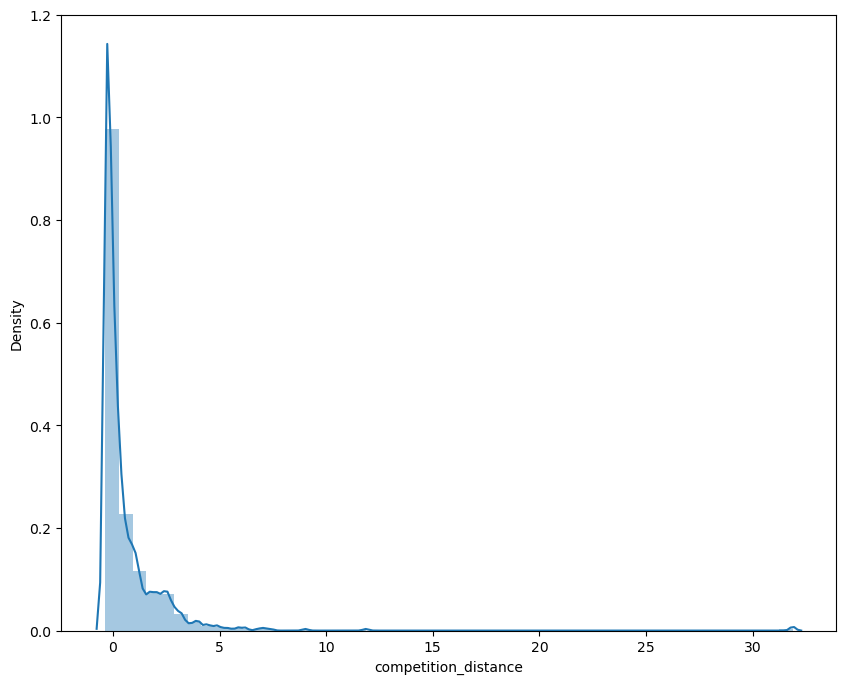

In [ ]:
plt.figure(figsize=(10, 8))
sns.distplot( df5['competition_distance'] );

## 6.1.3 Transformação

In [ ]:
##Encoding
# state_holiday- One Hot Encoding
df5 = pd.get_dummies( df5, prefix=['state_holiday'], columns=['state_holiday'], dtype=int  )

# store_type- Label Encoding
le = LabelEncoder()
df5['store_type'] = le.fit_transform( df5['store_type'] )


# assortment- Ordinal Encoding
assortment_dict = {'basic': 1, 'extra': 2, 'extended': 3}
df5['assortment'] = df5['assortment'].map( assortment_dict )

In [ ]:
df5.head()

,store,day_of_week,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,...,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week,state_holiday_christmas,state_holiday_easter_holiday,state_holiday_public_holiday,state_holiday_regular_day
0,1,5,2015-07-31,5263,1,1,2,1,-0.170968,9,...,31,2015-30,2008-09-01,0.918919,2015-07-27,0.287016,0,0,0,1
1,2,5,2015-07-31,6064,1,1,0,1,-0.283871,11,...,31,2015-30,2007-11-01,1.054054,2010-03-22,0.922551,0,0,0,1
2,3,5,2015-07-31,8314,1,1,0,1,1.903226,12,...,31,2015-30,2006-12-01,1.202703,2011-03-28,0.801822,0,0,0,1
3,4,5,2015-07-31,13995,1,1,2,3,-0.275806,9,...,31,2015-30,2009-09-01,0.743243,2015-07-27,0.287016,0,0,0,1
4,5,5,2015-07-31,4822,1,1,0,1,4.448387,4,...,31,2015-30,2015-04-01,-0.162162,2015-07-27,0.287016,0,0,0,1


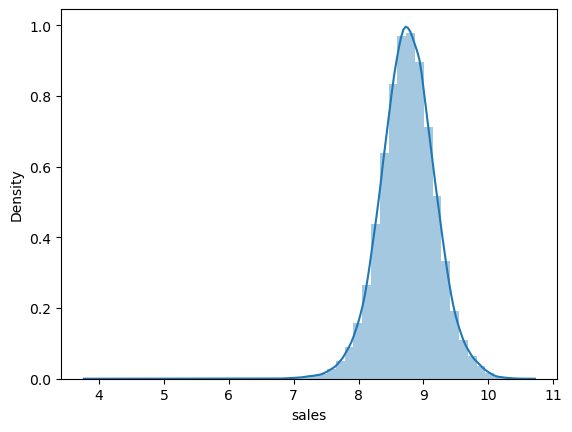

In [ ]:
#Response Variable Transformation - Grandeza
#Metodo Loghritmo
df5['sales'] = np.log1p( df5['sales'] )
sns.distplot( df5['sales']);

In [ ]:
#Nature Transformation - Natureza
# day of week
df5['day_of_week_sin'] = df5['month'].apply( lambda x: np.sin( x * ( 2. * np.pi/7) ) ) 
df5['day_of_week_cos'] = df5['month'].apply( lambda x: np.cos( x * ( 2. * np.pi/7) ) ) 

# month
df5['month_sin'] = df5['month'].apply( lambda x: np.sin( x * ( 2. * np.pi/12) ) ) 
df5['month_cos'] = df5['month'].apply( lambda x: np.cos( x * ( 2. * np.pi/12) ) ) 

# day
df5['day_sin'] = df5['month'].apply( lambda x: np.sin( x * ( 2. * np.pi/30) ) ) 
df5['day_cos'] = df5['month'].apply( lambda x: np.cos( x * ( 2. * np.pi/30) ) ) 

# week of year
df5['week_of_year_sin'] = df5['month'].apply( lambda x: np.sin( x * ( 2. * np.pi/52) ) ) 
df5['week_of_year_cos'] = df5['month'].apply( lambda x: np.cos( x * ( 2. * np.pi/52) ) ) 

In [ ]:
df5.head()

,store,day_of_week,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,...,state_holiday_public_holiday,state_holiday_regular_day,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_sin,day_cos,week_of_year_sin,week_of_year_cos
0,1,5,2015-07-31,8.568646,1,1,2,1,-0.170968,9,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123
1,2,5,2015-07-31,8.710290,1,1,0,1,-0.283871,11,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123
2,3,5,2015-07-31,9.025816,1,1,0,1,1.903226,12,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123
3,4,5,2015-07-31,9.546527,1,1,2,3,-0.275806,9,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123
4,5,5,2015-07-31,8.481151,1,1,0,1,4.448387,4,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123


# 7. Seleção de Features

In [ ]:
df6 = df5.copy()

In [ ]:
df6.head()

,store,day_of_week,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,...,state_holiday_public_holiday,state_holiday_regular_day,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_sin,day_cos,week_of_year_sin,week_of_year_cos
0,1,5,2015-07-31,8.568646,1,1,2,1,-0.170968,9,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123
1,2,5,2015-07-31,8.710290,1,1,0,1,-0.283871,11,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123
2,3,5,2015-07-31,9.025816,1,1,0,1,1.903226,12,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123
3,4,5,2015-07-31,9.546527,1,1,2,3,-0.275806,9,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123
4,5,5,2015-07-31,8.481151,1,1,0,1,4.448387,4,...,0,1,-2.449294e-16,1.0,-0.5,-0.866025,0.994522,0.104528,0.748511,0.663123


In [ ]:
# 6.1. Split dataframe into training and test dataset
cols_drop = ['week_of_year', 'day', 'month', 'day_of_week', 'promo_since','competition_since', 'year_week']
df6 = df6.drop( cols_drop, axis= 1 )

In [ ]:
df6[['store','date']].groupby('store').max().reset_index()['date'][0] - datetime.timedelta ( days=6*7 )

Timestamp('2015-06-19 00:00:00')

In [ ]:
df6.columns

Index(['store', 'date', 'sales', 'promo', 'school_holiday', 'store_type',
       'assortment', 'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'is_promo', 'year', 'competition_time_month',
       'promo_time_week', 'state_holiday_christmas',
       'state_holiday_easter_holiday', 'state_holiday_public_holiday',
       'state_holiday_regular_day', 'day_of_week_sin', 'day_of_week_cos',
       'month_sin', 'month_cos', 'day_sin', 'day_cos', 'week_of_year_sin',
       'week_of_year_cos'],
      dtype='object')

In [ ]:
# training dataset
x_train = df6[ df6['date'] < '2015-06-19'] 
y_train = x_train['sales']

# test dataset
x_test = df6[ df6['date'] >= '2015-06-19'] 
y_test = x_test['sales']

print( 'Training Min Date: {}'.format( x_train['date'].min() ) )
print( 'Training Min Date: {}'.format( x_train['date'].max() ) )

print( '\nTest Min Date: {}'.format( x_test['date'].min() ) )
print( 'Test Min Date: {}'.format( x_test['date'].max() ) )

Training Min Date: 2013-01-01 00:00:00
Training Min Date: 2015-06-18 00:00:00

Test Min Date: 2015-06-19 00:00:00
Test Min Date: 2015-07-31 00:00:00


In [ ]:
# training and test dataset for Boruta
#x_train_n = x_train.drop(['date','sales'], axis=1 ).values
#y_train_n = y_train.values.ravel()

# define RandomForestRegressor
#rf = RandomForestRegressor ( n_jobs=-1 )

# define Boruta
#boruta = BorutaPy( rf, n_estimators='auto', verbose=2, random_state=42 ).fit(x_train_n, y_train_n )

In [ ]:
#cols_selected = boruta.support_.tolist()

#best_features
#x_train_fs = x_train.drop (['sales', 'date'], axis=1 ) 
#cols_selected_boruta = x_train_fs.iloc[:, cols_selected].columns.to_list()

# not selected boruta
#cols_not_selected_boruta = list(np.setdiff1d(x_train_fs.columns, cols_selected_boruta))

In [ ]:
#Salvar as colunas para não rodar novamente o Boruta
cols_selected_boruta = [
    'store',
    'promo',
    'store_type',
    'assortment',
    'competition_distance',
    'competition_open_since_month',
    'competition_open_since_year',
    'promo2',
    'promo2_since_week',
    'promo2_since_year',
    'competition_time_month',
    'promo_time_week',
    'day_of_week_sin',
    'day_of_week_cos',
    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos',
    'week_of_year_sin',
    'week_of_year_cos']

# Columns to add
feat_to_add = ['date', 'sales']

#marger
cols_selected_boruta_full = cols_selected_boruta.copy()
cols_selected_boruta_full.extend ( feat_to_add )
cols_selected_boruta_full

['store',
 'promo',
 'store_type',
 'assortment',
 'competition_distance',
 'competition_open_since_month',
 'competition_open_since_year',
 'promo2',
 'promo2_since_week',
 'promo2_since_year',
 'competition_time_month',
 'promo_time_week',
 'day_of_week_sin',
 'day_of_week_cos',
 'month_sin',
 'month_cos',
 'day_sin',
 'day_cos',
 'week_of_year_sin',
 'week_of_year_cos',
 'date',
 'sales']

# 8. Machine Learning Modelling

In [ ]:
X_train = x_train[ cols_selected_boruta ]
X_test = x_test[ cols_selected_boruta ]

x_training = x_train[cols_selected_boruta_full]

## 8.1 Average Model

In [ ]:
aux1 = X_test.copy()
aux1['sales'] = y_test.copy()

#prediction
aux2 = aux1[['store', 'sales']].groupby( 'store' ).mean().reset_index().rename( columns={'sales': 'predictions'} )
aux1 = pd.merge( aux1, aux2, how='left', on= 'store' )
yhat_baseline = aux1['predictions']

#performance
baseline_result = ml_error('Average Model', np.expm1( y_test ), np.expm1( yhat_baseline)  )
baseline_result

,Model Name,MAE,MAPE,RMSE
0,Average Model,1354.800353,0.455051,1835.135542


## 8.2 Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso

In [ ]:
# model
lr = LinearRegression().fit( X_train, y_train )

# prediction
yhat_lr = lr.predict( X_test )

# performance
lr_result = ml_error( 'Linear Regression', np.expm1( y_test ), np.expm1( yhat_lr ) )
lr_result

,Model Name,MAE,MAPE,RMSE
0,Linear Regression,1898.522193,0.296771,2716.620535


### 8.2.1 Linear Regression - Cross Validation

In [ ]:
lr_result_cv = cross_validation(x_training, 5 , 'Linear Regression', lr, verbose=False)
lr_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Linear Regression,2063.67 +/- 252.54,0.3 +/- 0.02,2925.15 +/- 344.89


## 8.3 Linear Regression Regularized Model


In [ ]:
# model
lrr = Lasso( alpha=0.01 ).fit( X_train, y_train )

# prediction
yhat_lrr = lrr.predict( X_test )

# performance
lrr_result = ml_error( 'Linear Regression - Lasso', np.expm1( y_test ), np.expm1( yhat_lrr ) )
lrr_result


,Model Name,MAE,MAPE,RMSE
0,Linear Regression - Lasso,1907.791375,0.293827,2756.968319


### 8.3.1 Linear Regression Regularized - Cross Validation

In [ ]:
lrr_result_cv = cross_validation(x_training, 5 , 'Linear Regression Lasso', lrr, verbose=False)
lrr_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Linear Regression Lasso,2115.42 +/- 321.07,0.29 +/- 0.01,3056.23 +/- 470.75


## 8.4 Random Forest Regressor

In [ ]:
# model
rf = RandomForestRegressor( n_estimators=100, 
                            n_jobs=-1, 
                            random_state=42 ).fit(X_train, y_train )

# prediction
yhat_rf = rf.predict( X_test )

# performance
rf_result = ml_error( 'Random Forest Regressor', np.expm1( y_test ), np.expm1(yhat_rf ) )
rf_result

,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,902.331256,0.137935,1286.908392


### 8.4.1 Random Forest - Cross Validation

In [ ]:
rf_result_cv = cross_validation(x_training, 5 , 'Random Forest Regressor', rf, verbose=False)
rf_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Random Forest Regressor,1181.06 +/- 249.31,0.17 +/- 0.02,1660.94 +/- 371.37


## 8.5 XGBoost Regressor

In [ ]:
import xgboost as xgb

In [ ]:
# model
model_xgb = xgb.XGBRegressor( objective='reg:squarederror',
                             n_estimators=100,
                             eta=0.01,
                             max_depth=10,
                             subsample=0.7,
                             colsample_bytee=0.9 ).fit( X_train, y_train )
# prediction
yhat_xgb = model_xgb.predict( X_test )

# performance
xgb_result = ml_error( 'XGBoost Regressor', np.expm1( y_test ), np.expm1(yhat_xgb ) )
xgb_result

,Model Name,MAE,MAPE,RMSE
0,XGBoost Regressor,1653.937512,0.246299,2412.192423


### 8.5.1 XGBoost Regressor - Cross Validation

In [ ]:
xgb_result_cv = cross_validation(x_training, 5 , 'XGBoost Regressor', model_xgb, verbose=False)
xgb_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,XGBoost Regressor,1831.22 +/- 296.74,0.25 +/- 0.01,2634.13 +/- 444.53


## 8.6 Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# model
dt = DecisionTreeRegressor(
    max_depth=10,        
    random_state=42
).fit(X_train, y_train)

# prediction
yhat_dt = dt.predict(X_test)

# performance
dt_result = ml_error(
    'Decision Tree Regressor',
    np.expm1(y_test),
    np.expm1(yhat_dt)
)

dt_result

,Model Name,MAE,MAPE,RMSE
0,Decision Tree Regressor,1596.718182,0.238401,2273.58276


In [ ]:
dt_result_cv = cross_validation(x_training, 5 , 'Decision Tree Regressor', dt, verbose=False)
dt_result_cv

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Decision Tree Regressor,1811.52 +/- 294.62,0.25 +/- 0.02,2541.5 +/- 440.47


## 8.5 Compare Model’s Performance

In [ ]:
#Single Performance
modelling_result = pd.concat( [baseline_result, lr_result, lrr_result, rf_result, xgb_result,dt_result] )
modelling_result.sort_values( 'RMSE' )

,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,902.331256,0.137935,1286.908392
0,Average Model,1354.800353,0.455051,1835.135542
0,Decision Tree Regressor,1596.718182,0.238401,2273.582760
0,XGBoost Regressor,1653.937512,0.246299,2412.192423
0,Linear Regression,1898.522193,0.296771,2716.620535
0,Linear Regression - Lasso,1907.791375,0.293827,2756.968319


In [ ]:
# Real Performance - Cross Validation
modelling_result = pd.concat( [lr_result_cv, lrr_result_cv, rf_result_cv, xgb_result_cv,dt_result_cv] )
modelling_result.sort_values( 'RMSE CV' )

,Model Name,MAE CV,MAPE CV,RMSE CV
0,Random Forest Regressor,1181.06 +/- 249.31,0.17 +/- 0.02,1660.94 +/- 371.37
0,Decision Tree Regressor,1811.52 +/- 294.62,0.25 +/- 0.02,2541.5 +/- 440.47
0,XGBoost Regressor,1831.22 +/- 296.74,0.25 +/- 0.01,2634.13 +/- 444.53
0,Linear Regression,2063.67 +/- 252.54,0.3 +/- 0.02,2925.15 +/- 344.89
0,Linear Regression Lasso,2115.42 +/- 321.07,0.29 +/- 0.01,3056.23 +/- 470.75


# 9.  Hyperparameter Fine Tuning

## 9.1 Random Search 

In [ ]:
import random
import warnings
warnings.filterwarnings( 'ignore' )

In [ ]:
param = { 
    'n_estimators': [10, 20, 30],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', None, 0.5],
    'bootstrap': [True]
}    

MAX_EVAL = 2 

In [ ]:
final_result = pd.DataFrame()

for i in range ( MAX_EVAL ):
    #choose valeuys for parametgers radomly
    hp = {k: random.sample ( v, 1 )[0] for k, v in param.items()}
    print( hp )
    # model
    rf = RandomForestRegressor(
                                n_estimators=hp['n_estimators'],        
                                max_depth=hp['max_depth'],           
                                min_samples_split=hp['min_samples_split'],   
                                min_samples_leaf=hp['min_samples_leaf'],    
                                max_features=hp['max_features'],        
                                bootstrap=hp['bootstrap'],
                                random_state=42,
                                n_jobs=-1 )
        
    # performance
    result = cross_validation(x_training, 2 , 'Random Forest Regressor', rf, verbose=False)
    final_result = pd.concat( [final_result, result ] )

final_result

{'n_estimators': 30, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}
{'n_estimators': 20, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}


,Model Name,MAE CV,MAPE CV,RMSE CV
0,Random Forest Regressor,1214.67 +/- 105.04,0.17 +/- 0.0,1730.15 +/- 200.25
0,Random Forest Regressor,1076.78 +/- 88.55,0.15 +/- 0.0,1498.57 +/- 187.5


## 9.2 Final Model

In [ ]:
param_tuned = { 
    'n_estimators': 100,
    'max_depth': 5,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 1,
    'bootstrap': 'True' 
}

In [ ]:
#model
rf_tuned = RandomForestRegressor(
                                n_estimators=param_tuned['n_estimators'],
                                random_state=42,
                                n_jobs=-1 ).fit(X_train, y_train )
# predict
yhat_rf_tuned = rf_tuned.predict ( X_test )

# performance
rf_result_tuned = ml_error( 'Random Forest Regressor', np.expm1( y_test ), np.expm1( yhat_rf_tuned ) )
rf_result_tuned

,Model Name,MAE,MAPE,RMSE
0,Random Forest Regressor,902.331256,0.137935,1286.908392


In [ ]:
#MPE ( Erro validação do modelo superestimando ou subestimando )
MPE = mean_percentage_error( np.expm1( y_test ), np.expm1( yhat_rf_tuned ) )
MPE

np.float64(-0.028147801812108828)

# 10.Resultados Finais

In [ ]:
df9 = x_test[cols_selected_boruta_full]

#rescale
df9['sales'] = np.expm1(df9['sales'])
df9['predictions'] = np.expm1( yhat_rf_tuned )

## 10.1 Bussiness Perfomace

In [ ]:
#sum of preditions
df91 =  df9[['store','predictions']].groupby('store').sum().reset_index()
df91.head()

# MAE and MAPE
df9_aux1 =  df9[['store','sales', 'predictions']].groupby('store').apply( lambda x: mean_absolute_error( x['sales'], x['predictions'])).reset_index().rename(columns={0:'MAE'} )
df9_aux2 =  df9[['store','sales', 'predictions']].groupby('store').apply( lambda x: mean_absolute_percentage_error( x['sales'], x['predictions'])).reset_index().rename(columns={0:'MAPE'} )

#merge
df9_aux3 = pd.merge( df9_aux1, df9_aux2, how='inner', on='store')
df92 = pd.merge(df91, df9_aux3, how='inner', on='store')

# Scenarios
df92['worst_scenario'] = df92['predictions'] - df92['MAE']
df92['best_scenario'] = df92['predictions'] + df92['MAE']


# Order Columns
df92 = df92[['store','predictions','worst_scenario','best_scenario','MAE','MAPE']]
df92.sample(5)

,store,predictions,worst_scenario,best_scenario,MAE,MAPE
595,596,160192.064600,159480.139344,160903.989856,711.925256,0.131667
881,882,283035.870391,281355.494155,284716.246627,1680.376236,0.305446
82,83,143068.619522,142645.436222,143491.802821,423.183300,0.129191
909,910,219725.504028,218966.981203,220484.026853,758.522825,0.123398
804,805,203225.675346,202653.174712,203798.175980,572.500634,0.100673


In [ ]:
df92.sort_values( 'MAPE', ascending=False).head()

,store,predictions,worst_scenario,best_scenario,MAE,MAPE
291,292,110583.191201,107058.667084,114107.715318,3524.524117,0.622124
971,972,177953.707318,176162.910713,179744.503923,1790.796605,0.535775
875,876,209649.853600,204738.154375,214561.552826,4911.699226,0.511225
908,909,259648.436809,252628.707767,266668.165852,7019.729043,0.496959
182,183,250235.851539,247774.197337,252697.505742,2461.654203,0.472060


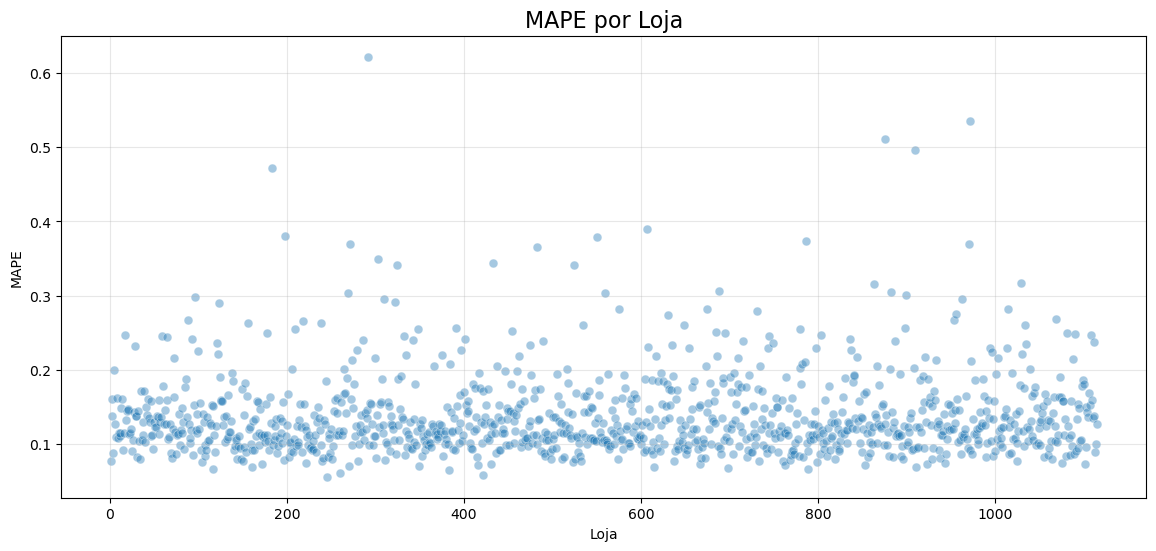

In [ ]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    x='store',
    y='MAPE',
    data=df92,
    alpha=0.4,      
    s=40             
)

plt.title('MAPE por Loja', fontsize=16)
plt.xlabel('Loja')
plt.ylabel('MAPE')
plt.grid(alpha=0.3)

plt.show()

## 10.2 Total Performarce

In [ ]:
df93 = df92[['predictions','worst_scenario','best_scenario']].apply(lambda x: np.sum( x ), axis=0).reset_index().rename( columns={'index': 'Scenario',0: 'Valores'})
df93['Valores'] = df93['Valores'].map( 'R${:,.2f}'.format )
df93.head()

,Scenario,Valores
0,predictions,"R$288,807,339.20"
1,worst_scenario,"R$287,798,410.22"
2,best_scenario,"R$289,816,268.18"
